# Preprocessing and building of the candidate dataset
This notebook downloads and preprocesses weekly Sentinel-5P XCH₄ observations over the Po Valley for 2019–2024. Missing weekly timestamps are explicitly restored, and a provisional geographic ROI is combined with a minimum temporal-coverage threshold to identify candidate grid cells. The resulting analysis-ready dataset is saved as NetCDF for subsequent feature engineering and model training. 

## 1. Multiyear data acquisition  

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from po_valley_methane_forecasting.paths import find_project_root
from po_valley_methane_forecasting.data_access import(
    connect_to_copernicus,
    download_ch4_multiyear,
    load_xarray_dataset,
    save_xarray_dataset
)
from po_valley_methane_forecasting.preprocessing import(
    load_po_valley_roi,
    build_candidate_dataset,
    create_roi_mask,
    create_coverage_mask
)

In [2]:
project_root=find_project_root()

interim_data_dir = project_root / "data" / "interim"
interim_data_dir.mkdir(parents=True, exist_ok=True)

multiyear_output_path = interim_data_dir / "sentinel5p_ch4_po_valley_weekly_2019_2024.nc"

print("Project root:", project_root)
print("Output file:", multiyear_output_path)

Project root: c:\Users\Pietro\OneDrive\Desktop\po_valley_methane_forecasting
Output file: c:\Users\Pietro\OneDrive\Desktop\po_valley_methane_forecasting\data\interim\sentinel5p_ch4_po_valley_weekly_2019_2024.nc


In [3]:
po_valley_extent = {
    "west": 7.5,
    "south": 44.3,
    "east": 13.0,
    "north": 46.7,
    "crs": "EPSG:4326",
}

In [4]:
if not multiyear_output_path.exists():
    connection = connect_to_copernicus()

    download_ch4_multiyear(
        connection=connection,
        first_year=2019,
        last_year=2024,
        spatial_extent=po_valley_extent,
        output_path=multiyear_output_path,
    )
else:
    print(
        "Multiyear dataset already available — "
        "skipping download."
    )

Multiyear dataset already available — skipping download.


In [5]:
multiyear_ds = load_xarray_dataset(multiyear_output_path)

## 2. Dataset exploration

In [6]:
multiyear_times = pd.DatetimeIndex(
    multiyear_ds["t"].values
).sort_values()

duplicate_times = multiyear_times[
    multiyear_times.duplicated(keep=False)
]

complete_weekly_index = pd.date_range(
    start=multiyear_times.min(),
    end=multiyear_times.max(),
    freq="7D",
)

missing_times = complete_weekly_index.difference(
    multiyear_times
)

print("Total timestamps:", len(multiyear_times))
print("Unique timestamps:", multiyear_times.nunique())
print("First timestamp:", multiyear_times.min())
print("Last timestamp:", multiyear_times.max())

print("\nDuplicate timestamps:")
print(duplicate_times)

print("\nMissing timestamps:")
print(missing_times)

Total timestamps: 309
Unique timestamps: 309
First timestamp: 2018-12-30 00:00:00
Last timestamp: 2024-12-29 00:00:00

Duplicate timestamps:
DatetimeIndex([], dtype='datetime64[ns]', freq=None)

Missing timestamps:
DatetimeIndex(['2022-07-31', '2022-08-07', '2022-08-14', '2023-08-20',
               '2023-10-15'],
              dtype='datetime64[ns]', freq=None)


In [7]:
complete_weekly_index = pd.date_range(
    start=multiyear_times.min(),
    end=multiyear_times.max(),
    freq="7D",
)

multiyear_ds = (
    multiyear_ds
    .sortby("t")
    .reindex(t=complete_weekly_index)
)

In [8]:
complete_times = pd.DatetimeIndex(
    multiyear_ds["t"].values
)

time_difference_days = (
    pd.Series(complete_times)
    .diff()
    .dt.days
    .dropna()
)

print("Total timestamps:", len(complete_times))
print("Unique timestamps:", complete_times.nunique())
print("Weekly spacing:", time_difference_days.eq(7).all())
print("Grid shape:", multiyear_ds.sizes["y"],
      "×", multiyear_ds.sizes["x"])

assert len(complete_times) == 314
assert complete_times.is_unique
assert time_difference_days.eq(7).all()
assert multiyear_ds.sizes["y"] == 70
assert multiyear_ds.sizes["x"] == 101

Total timestamps: 314
Unique timestamps: 314
Weekly spacing: True
Grid shape: 70 × 101


In [9]:
inserted_weeks = pd.DatetimeIndex([
    "2022-07-31",
    "2022-08-07",
    "2022-08-14",
    "2023-08-20",
    "2023-10-15",
])

for week in inserted_weeks:
    week_is_all_nan = bool(
        multiyear_ds["CH4"]
        .sel(t=week)
        .isnull()
        .all()
        .values
    )

    print(week.date(), "all NaN:", week_is_all_nan)
    assert week_is_all_nan

2022-07-31 all NaN: True
2022-08-07 all NaN: True
2022-08-14 all NaN: True
2023-08-20 all NaN: True
2023-10-15 all NaN: True


In [10]:
training_temporal_coverage, coverage_mask = (
    create_coverage_mask(
        multiyear_ds,
        coverage_threshold=0.25,
        start_date="2018-12-30",
        end_date="2021-12-26",
    )
)

## 3. Construction and analysis of the region of interest

In [11]:
po_valley_roi=load_po_valley_roi()

In [12]:
print("CRS:", po_valley_roi.crs)
print("Geometry type:", po_valley_roi.geometry.geom_type.tolist())
print("Bounds:", po_valley_roi.total_bounds)

CRS: EPSG:4326
Geometry type: ['Polygon']
Bounds: [ 7.269615 44.019432 13.493886 46.241643]


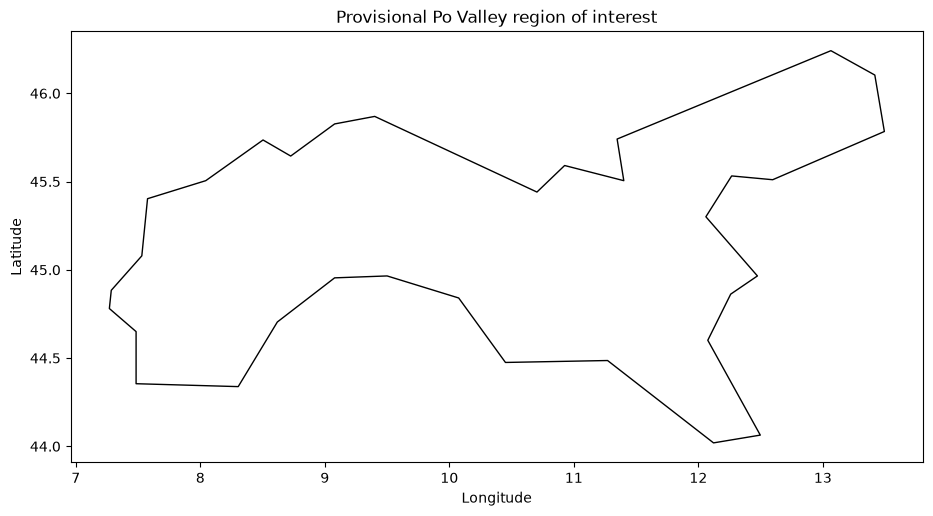

In [13]:
po_valley_roi.plot(
    figsize=(11, 6),
    facecolor="none",
    edgecolor="black",
)

plt.title("Provisional Po Valley region of interest")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [14]:
inside_roi = create_roi_mask(
    multiyear_ds,
    po_valley_roi,
)

coverage_inside_roi = (
    training_temporal_coverage
    .where(inside_roi)
)

In [15]:
coverage_thresholds = [
    0.0,
    0.10,
    0.25,
    0.50,
    0.75,
]

for threshold in coverage_thresholds:
    number_of_cells = int(
        (
            coverage_inside_roi
            >= threshold
        )
        .sum()
        .values
    )

    print(
        f"Cells with coverage >= {threshold:.0%}: "
        f"{number_of_cells}"
    )

Cells with coverage >= 0%: 2974
Cells with coverage >= 10%: 2718
Cells with coverage >= 25%: 2620
Cells with coverage >= 50%: 2309
Cells with coverage >= 75%: 391


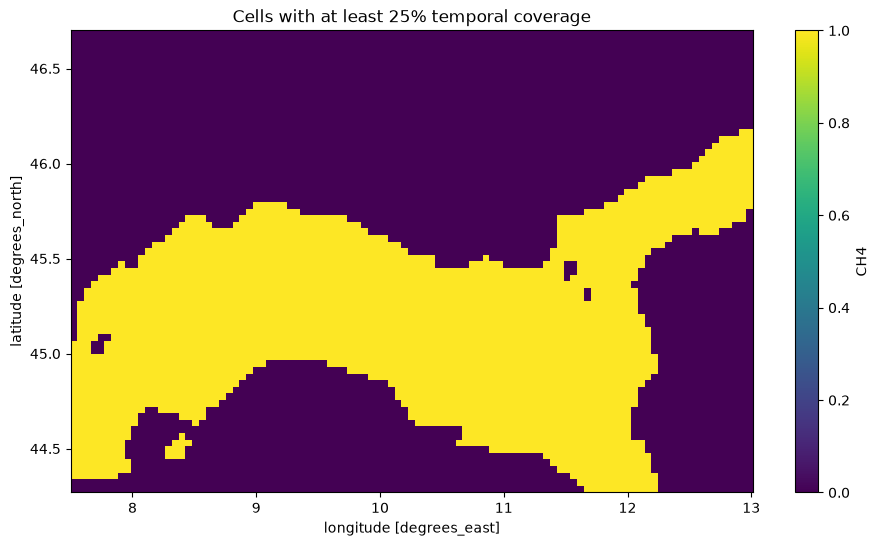

In [16]:
minimum_cell_coverage = 0.25

sufficient_coverage_mask = (
     coverage_inside_roi >= minimum_cell_coverage
)

sufficient_coverage_mask.plot(
    figsize=(11, 6),
)

plt.title(
    "Cells with at least 25% temporal coverage"
)
plt.show()

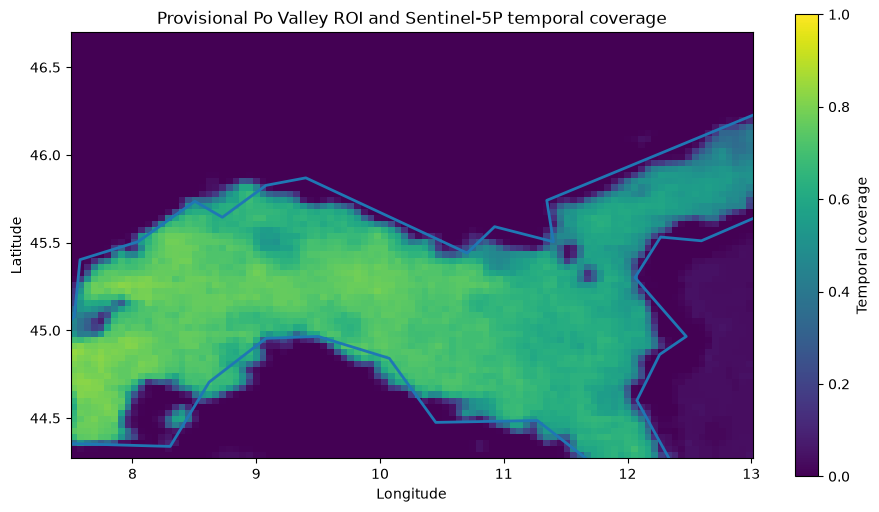

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

training_temporal_coverage.rename("Temporal coverage").plot(
    ax=ax,
    vmin=0,
    vmax=1,
)

po_valley_roi.boundary.plot(
    ax=ax,
    linewidth=2,
)

ax.set_title(
    "Provisional Po Valley ROI and Sentinel-5P temporal coverage"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

## 4. Construction of the candidate dataset

In [18]:
candidate_ds = build_candidate_dataset(
    dataset=multiyear_ds,
    roi=po_valley_roi,
    coverage_threshold=0.25,
    coverage_start="2018-12-30",
    coverage_end="2021-12-26",
)

Candidate cells are selected using temporal coverage from the 2019–2021 training period only. Because weekly aggregates are labelled by the start of their weekly interval, the first relevant timestamp is 2018-12-30.

In [19]:
assert candidate_ds.sizes["t"] == 314
assert int(
    candidate_ds["candidate_mask"].sum().values
) == 2620

In [20]:
candidate_ds

<xarray.Dataset> Size: 9MB
Dimensions:                     (t: 314, x: 101, y: 70)
Coordinates:
  * t                           (t) datetime64[ns] 3kB 2018-12-30 ... 2024-12-29
  * x                           (x) float64 808B 7.527 7.582 ... 12.93 12.98
  * y                           (y) float64 560B 46.68 46.65 ... 44.32 44.29
Data variables:
    CH4                         (t, y, x) float32 9MB nan nan nan ... nan nan
    roi_mask                    (y, x) int8 7kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    candidate_mask              (y, x) int8 7kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    training_temporal_coverage  (y, x) float64 57kB 0.0 0.0 ... 0.03185 0.04459

In [21]:
number_of_roi_cells = int(
    candidate_ds["roi_mask"].sum().values
)

number_of_candidate_cells = int(
    candidate_ds["candidate_mask"].sum().values
)

print(
    "Cells inside ROI:",
    number_of_roi_cells,
)

print(
    "Candidate cells:",
    number_of_candidate_cells,
)

print(
    "Cells excluded for low coverage:",
    number_of_roi_cells
    - number_of_candidate_cells,
)

Cells inside ROI: 2974
Candidate cells: 2620
Cells excluded for low coverage: 354


In [22]:
candidate_ds.attrs.update({
    "description": (
        "Weekly Sentinel-5P XCH4 observations over "
        "candidate Po Valley grid cells, 2019–2024."
    ),
    "coverage_reference_period": (
        "2018-12-30 to 2021-12-26"
    ),
    "minimum_temporal_coverage": 0.25,
    "number_of_roi_cells": 2974,
    "number_of_candidate_cells": 2620,
})

In [23]:
candidate_output_path = (
    interim_data_dir
    / "sentinel5p_ch4_po_valley_candidate_2019_2024.nc"
)

In [24]:
save_xarray_dataset(
    candidate_ds,
    candidate_output_path,
)

assert candidate_output_path.exists()

print(
    "Candidate dataset saved to:",
    candidate_output_path,
)

Candidate dataset saved to: c:\Users\Pietro\OneDrive\Desktop\po_valley_methane_forecasting\data\interim\sentinel5p_ch4_po_valley_candidate_2019_2024.nc
